In [1]:
import pandas as pd

df = pd.read_csv("secondary_ads_dataset.csv")

df.head()

,category,app_name,country,continent,review_id,review_date,rating,review_text,likes,reviewer_name,scraped_at,clean_text,ad_mentioned,ad_keyword,sentiment
0,Social Media,Instagram,us,North America,e3b1e0ac-69b8-4607-b76c-9847eeaf0e4e,2026-03-11 23:58:06,1,very nice app,0,KhushbooRani Khushboo,2026-03-13 00:02:03.924872,nice app,0,none,positive
1,Social Media,Instagram,us,North America,5157f955-0034-4dec-a286-848441463191,2026-03-11 23:58:02,5,Really helps getting to know other people's li...,0,Sena Risk,2026-03-13 00:02:03.924884,really help getting know people lifestyle ou,0,none,positive
2,Social Media,Instagram,us,North America,a53ce01c-3c11-4a43-a5b7-e20ef80b56f6,2026-03-11 23:57:48,5,this one,0,Ankit Saini,2026-03-13 00:02:03.924886,one,0,none,neutral
3,Social Media,Instagram,us,North America,454407b1-e1a6-4f9b-8485-39ffa412b563,2026-03-11 23:56:29,1,not good for use..,0,Pavan Bidve,2026-03-13 00:02:03.924888,good use,0,none,positive
4,Social Media,Instagram,us,North America,262f9eec-8c03-4728-8d7b-03d38008182f,2026-03-11 23:56:10,5,very good 💯 👌🏻👍🏻,0,vandana kashyap,2026-03-13 00:02:03.924890,good,0,none,positive


In [2]:
df['review_date'] = pd.to_datetime(df['review_date'])

In [3]:
sentiment_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

df["sentiment_score"] = df["sentiment"].map(sentiment_map)

In [4]:
daily_df = df.groupby("review_date").agg(
    y=("ad_mentioned", "sum"),
    sentiment_avg=("sentiment_score", "mean")
).reset_index()

daily_df.rename(columns={"review_date":"ds"}, inplace=True)

daily_df.head()

,ds,y,sentiment_avg
0,2024-06-22 12:16:13,0,-1.0
1,2024-06-22 19:57:29,11,1.0
2,2024-06-22 19:59:05,11,0.0
3,2024-06-23 23:21:54,11,-1.0
4,2024-06-25 01:16:24,0,0.0


In [5]:
full_dates = pd.date_range(start=daily_df.ds.min(), end=daily_df.ds.max())

daily_df = daily_df.set_index("ds").reindex(full_dates).fillna(0).rename_axis("ds").reset_index()

daily_df.head()

,ds,y,sentiment_avg
0,2024-06-22 12:16:13,0.0,-1.0
1,2024-06-23 12:16:13,0.0,0.0
2,2024-06-24 12:16:13,0.0,0.0
3,2024-06-25 12:16:13,0.0,0.0
4,2024-06-26 12:16:13,0.0,0.0


In [6]:
train = daily_df[:-30]
test = daily_df[-30:]

In [7]:
!pip install prophet

In [8]:
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

model.fit(train)

In [9]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-06-22 12:16:13,0.0,-1.349281e-09,1.248195e-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-06-23 12:16:13,0.0,-1.367802e-09,1.216606e-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-06-24 12:16:13,0.0,-1.342653e-09,1.234863e-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-06-25 12:16:13,0.0,-1.219832e-09,1.369584e-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-06-26 12:16:13,0.0,-1.293690e-09,1.214968e-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


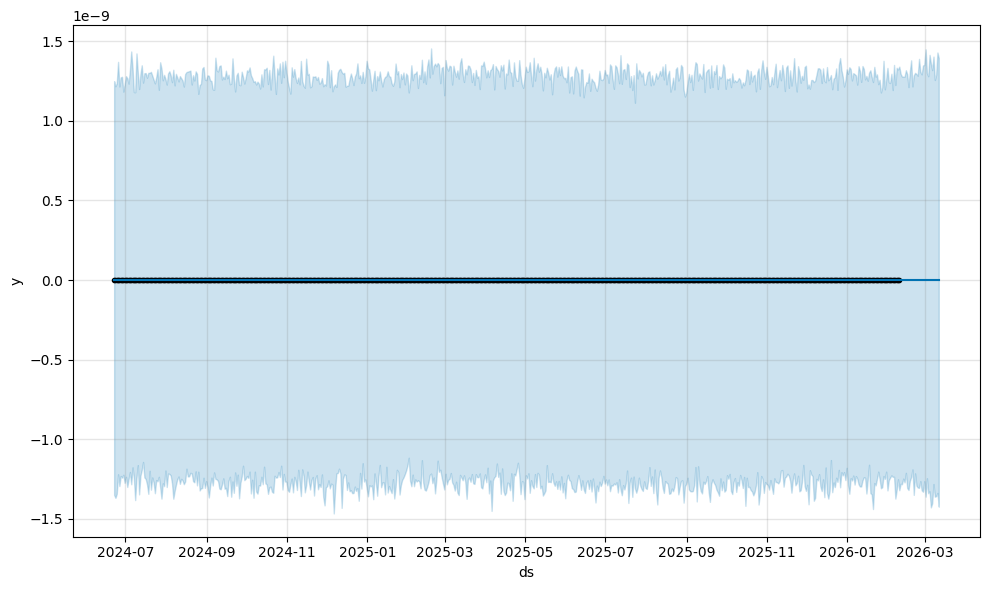

In [10]:
fig = model.plot(forecast)

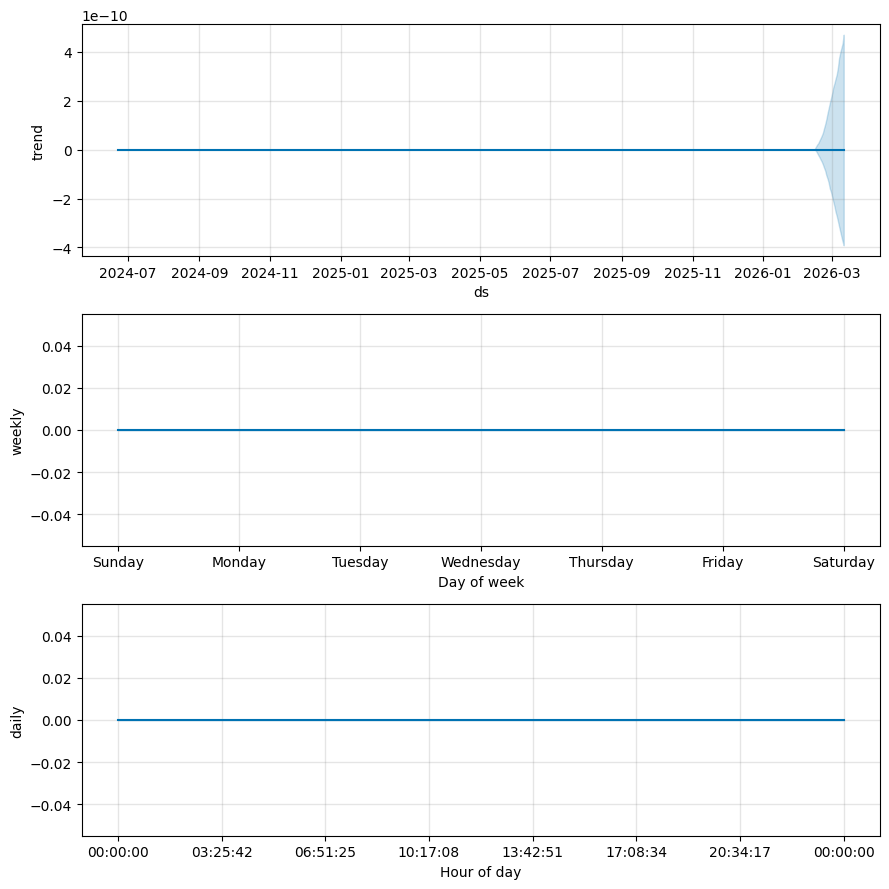

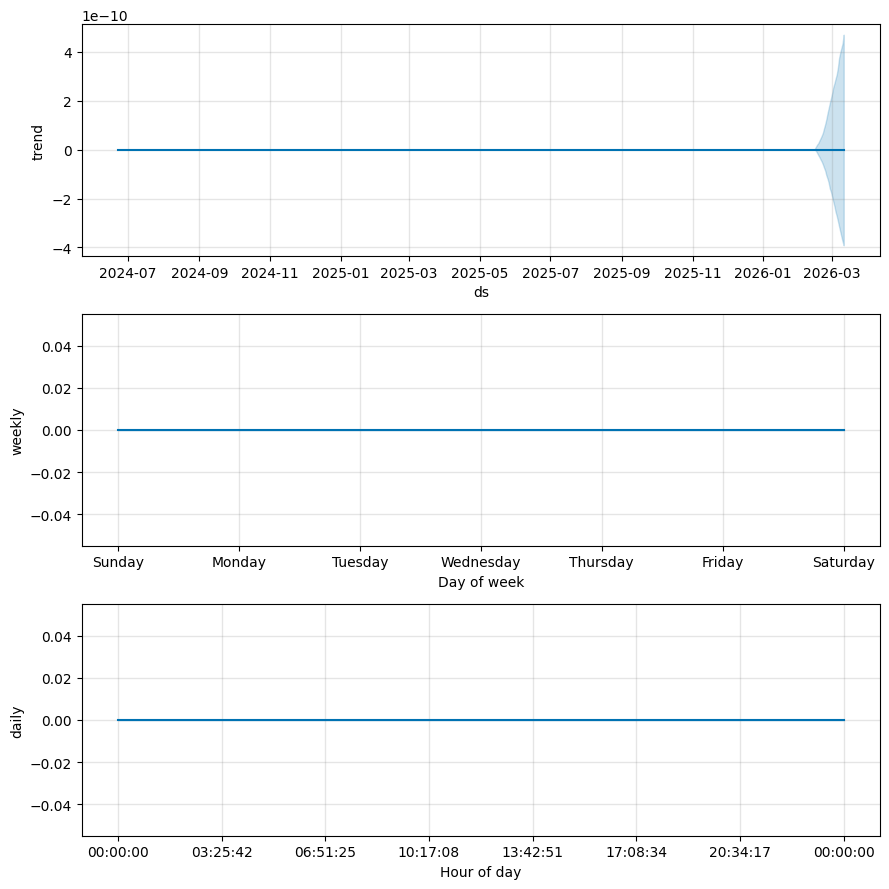

In [11]:
model.plot_components(forecast)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast_test = forecast.iloc[-30:]

mae = mean_absolute_error(test["y"], forecast_test["yhat"])
rmse = np.sqrt(mean_squared_error(test["y"], forecast_test["yhat"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.0
RMSE: 0.0


In [13]:
forecast.to_csv("ad_mentions_forecast.csv", index=False)

In [14]:
model = Prophet()

model.add_regressor("sentiment_avg")

model.fit(train)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [15]:
forecast_next_month = forecast.tail(30)["yhat"].sum()

avg_sentiment = daily_df["sentiment_avg"].mean()

print("Forecasted Mentions Next 30 Days:", forecast_next_month)
print("Average Sentiment:", avg_sentiment)

Forecasted Mentions Next 30 Days: 0.0
Average Sentiment: -0.0015923566878980893
